# DS3040 – Lab 7: Strict Audit, Deep Review & Corrected Solution
### Attention Mechanisms & Transformer-based Emotion Classification
---



## 🧠 PART 0 — Deep Conceptual Foundation

---

### 1. Scaled Dot-Product Attention

**Intuition:** Imagine you're at a library. You have a **query** (what you're looking for), and the shelves have **keys** (labels on books) and **values** (the actual book content). You check how well your query matches each key, and retrieve a *weighted mix* of values.

**How it works:**
```
Attention(Q, K, V) = softmax( QKᵀ / √dk ) · V

Step 1: QKᵀ         → raw similarity scores (dot products)
        shape (seq_len, seq_len)
Step 2: / √dk        → scale down to prevent softmax saturation
Step 3: softmax(·)   → convert to probability distribution (sum = 1 per row)
Step 4: · V          → weighted sum of values
        shape (seq_len, d_v)
```

**Technical depth — WHY √dk?**
The dot product `Q·K` has variance proportional to `dk` (each of the `dk` terms contributes variance ~1).
Without scaling: `Var(QK) = dk`. As dk grows, dot products can be very large.
Large inputs to softmax → output becomes nearly one-hot → near-zero gradients for most tokens → model stops learning.
Dividing by √dk normalizes variance back to ~1 regardless of dk.

**What if we don't scale?** With dk=64:
- Unscaled dot products could be ~±8 magnitude
- softmax([8, -7, -8, ...]) ≈ [0.9999, 0.0001, 0.0000, ...]
- Gradient of softmax near one-hot → ~0 → vanishing gradient in attention

---

### 2. Self-Attention

**Intuition:** Each token asks: "Which other tokens in this sentence should I pay attention to?"

In self-attention, Q, K, V are all derived from the **same** input via learned linear projections:
```
Q = X · W_Q,  K = X · W_K,  V = X · W_V
```
This lets each token dynamically attend to any other token, regardless of distance.

**Contrast with RNN:** RNN can only look back sequentially — word at position 10 has 10 steps to reach word at position 1. Attention: **O(1) path** between any two positions.

---

### 3. Positional Encoding — Why Needed?

**The problem:** Attention treats the input as a **set**, not a sequence. `"cat bites dog"` and `"dog bites cat"` produce the same attention outputs if we don't tell the model word order.

**The fix:** Add a position-specific vector to each embedding:
```
PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
```

**Why sin/cos?** They allow the model to express relative positions via linear transformations:
`PE(pos+k)` is a linear function of `PE(pos)` for any fixed offset `k`.

**What if we remove positional encoding?** The model becomes permutation-invariant — the sentence `"not good"` and `"good not"` produce identical representations. Classification degrades significantly.

---

### 4. Residual Connections + Layer Normalization

**Residual:** `output = LayerNorm(x + sublayer(x))`

**Why residual?** Same reason as ResNet: gradient flows directly through `x` without passing through `sublayer`. Without it, gradients in deep transformers vanish. Also, if `sublayer` is useless, it can output ~0 and the block becomes identity.

**Why LayerNorm (not BatchNorm)?**
- BatchNorm normalizes across the **batch** dimension → requires large batches, doesn't work well with variable-length sequences
- LayerNorm normalizes across the **feature** dimension for each sample independently → works with any batch size including 1

**Pre-LN vs Post-LN:**
- Parv uses Post-LN: `LayerNorm(x + sublayer(x))` ← original Transformer paper
- Pre-LN (modern): `x + sublayer(LayerNorm(x))` ← more stable training, used in GPT-2 etc.

---

### 5. Mean Pooling vs Alternatives

| Method | How | When to use |
|--------|-----|-------------|
| Mean pooling | `x.mean(dim=1)` | Balanced view of all tokens, good for long text |
| Max pooling | `x.max(dim=1).values` | Captures strongest single signal, good for detecting presence of features |
| [CLS] token | Take first token's embedding | BERT-style, learns to aggregate during training |
| Last token | Take last token's embedding | GPT-style autoregressive |

**This lab requires mean pooling explicitly.**

---

In [1]:
# ============================================================
# CELL 0 – Imports
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
print(f"PyTorch: {torch.__version__}")

PyTorch: 2.6.0+cpu


---
# Question 1 — Scaled Dot-Product Attention from Scratch
## Q1(a) — Attention Function Implementation

In [3]:
# ============================================================
# CELL 1 – Scaled Dot-Product Attention
# ============================================================
# Formula: Attention(Q, K, V) = softmax( QKᵀ / √dk ) · V
#
#  Parv's implementation is CORRECT for the 2D (single-head) case.
# One improvement: handle both 2D (seq, dk) and 3D (batch, seq, dk) inputs.
# The use of K.transpose(-2, -1) already handles both cases.

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Scaled Dot-Product Attention.
    
    Args:
        Q: Query tensor  (seq_q, dk)   or (batch, seq_q, dk)
        K: Key tensor    (seq_k, dk)   or (batch, seq_k, dk)
        V: Value tensor  (seq_v, dv)   or (batch, seq_v, dv)
        mask: Optional boolean mask to zero out certain attention positions
              (used in decoder to prevent attending to future tokens)
    
    Returns:
        output:  (seq_q, dv) or (batch, seq_q, dv) — context vectors
        weights: (seq_q, seq_k) — attention weight matrix (sums to 1 per row)
    
    Step-by-step:
        1. QKᵀ:              raw similarity score between every (query, key) pair
        2. / sqrt(dk):       scale to prevent softmax saturation
        3. softmax(dim=-1):  each row is a prob distribution over keys
                             'row i' = how much query i attends to each key
        4. · V:              weighted sum of values
    """
    dk = Q.size(-1)                                   # Dimensionality of queries/keys
    
    # Step 1+2: Scaled similarity scores
    # Q: (seq_q, dk), K.T: (dk, seq_k) → scores: (seq_q, seq_k)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(dk)
    
    # Optional mask (for causal / padding masking)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    
    # Step 3: Softmax over key dimension (dim=-1)
    # WHY dim=-1? Each ROW represents one query attending to all keys.
    # We want probabilities across keys for each query → last dimension.
    weights = torch.softmax(scores, dim=-1)            # (seq_q, seq_k)
    
    # Step 4: Weighted sum of values
    output = torch.matmul(weights, V)                  # (seq_q, dv)
    
    return output, weights


# ─── Test with random tensors ─────────────────────────────────
torch.manual_seed(42)
seq_len, dk = 6, 8

Q = torch.randn(seq_len, dk)
K = torch.randn(seq_len, dk)
V = torch.randn(seq_len, dk)

output, weights = scaled_dot_product_attention(Q, K, V)

print("Shape of attention output (context vectors):", output.shape)   # (6, 8)
print("Shape of attention weight matrix:            ", weights.shape)  # (6, 6)

# Verify: each row of weights sums to 1 (it's a probability distribution)
print(f"\nRow-sum check (should all be 1.0): {weights.sum(dim=-1).tolist()}")

# Verify: all weights are non-negative
print(f"All weights non-negative: {(weights >= 0).all().item()}")

Shape of attention output (context vectors): torch.Size([6, 8])
Shape of attention weight matrix:             torch.Size([6, 6])

Row-sum check (should all be 1.0): [1.0, 0.9999999403953552, 1.0, 0.9999999403953552, 1.0, 1.0]
All weights non-negative: True


## Q1(b) — Visualize Self-Attention on "The cat sat on the mat"

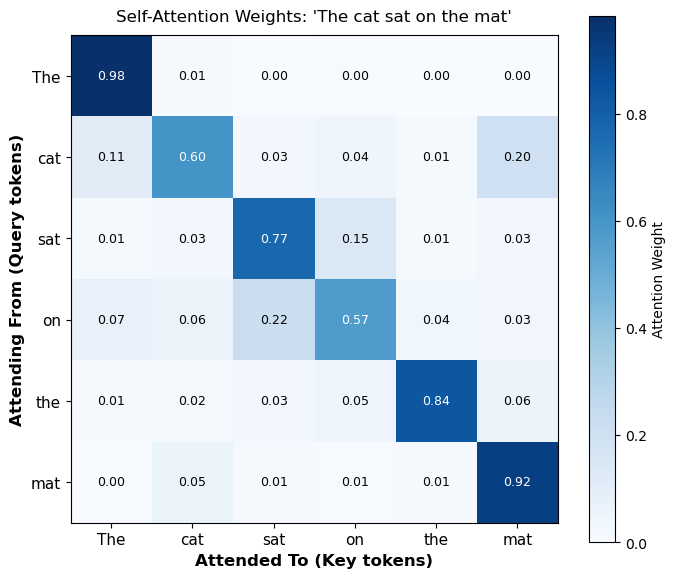


=== Reading the Attention Heatmap ===
Row i, Col j = how much token[i] attends to token[j]
Each row sums to 1.0 (probability distribution over all keys)

NOTE: With RANDOM embeddings, attention pattern is also random.
With TRAINED embeddings, you'd see meaningful patterns, e.g.:
 'sat' might attend strongly to 'cat' (subject-verb relationship)
 'the' might attend strongly to the noun it modifies


In [4]:
# ============================================================
# CELL 2 – Attention Visualization
# ============================================================
#
# ✅ Parv's core logic is CORRECT (self-attention: Q=K=V=embeddings).
#
# ⚠️ BUGS FIXED:
#   Bug 6: Missing plt.xlabel() and plt.ylabel()
#          The question says 'Label both axes with token names.'
#          xticks/yticks add TICK LABELS but not AXIS LABELS.
#          Both are needed for a fully labeled plot.
#
#   Added: axis labels, colorbar label, tight_layout, better colormap,
#          annotation of weight values, and semantic axis interpretation.

torch.manual_seed(42)  # ✅ As required

tokens     = ["The", "cat", "sat", "on", "the", "mat"]
embeddings = torch.randn(6, 8)  # Random dk=8 vectors for each token

# Self-attention: same tensor used as Q, K, and V
# WHY Q=K=V? Self-attention lets each token query ALL other tokens
# using the same representation space.
_, attn_weights = scaled_dot_product_attention(embeddings, embeddings, embeddings)

attn_np = attn_weights.detach().numpy()  # (6, 6)

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(attn_np, cmap='Blues', vmin=0, vmax=attn_np.max())

# ── Tick labels ──────────────────────────────────────────────
ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(tokens, fontsize=11)
ax.set_yticklabels(tokens, fontsize=11)

# ── Axis labels (FIXED — was missing in Parv's code) ─────────
# Semantics:
#   x-axis (columns): the token being ATTENDED TO (key)
#   y-axis (rows):    the token that IS ATTENDING (query)
# Row i, Col j = 'token i attends to token j' → matches question
ax.set_xlabel("Attended To (Key tokens)", fontsize=12, fontweight='bold')
ax.set_ylabel("Attending From (Query tokens)", fontsize=12, fontweight='bold')

ax.set_title("Self-Attention Weights: 'The cat sat on the mat'", fontsize=12, pad=10)

# ── Annotate cells with weight values ────────────────────────
for i in range(6):
    for j in range(6):
        ax.text(j, i, f"{attn_np[i, j]:.2f}",
                ha='center', va='center',
                color='white' if attn_np[i, j] > 0.25 else 'black',
                fontsize=9)

# ── Colorbar ─────────────────────────────────────────────────
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Attention Weight', fontsize=10)

plt.tight_layout()
plt.savefig('q1_attention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Reading the Attention Heatmap ===")
print("Row i, Col j = how much token[i] attends to token[j]")
print("Each row sums to 1.0 (probability distribution over all keys)")
print("\nNOTE: With RANDOM embeddings, attention pattern is also random.")
print("With TRAINED embeddings, you'd see meaningful patterns, e.g.:")
print(" 'sat' might attend strongly to 'cat' (subject-verb relationship)")
print(" 'the' might attend strongly to the noun it modifies")

---
# Question 2 — Transformer-based Emotion Classification
## Q2(a) — Data Loading and Preprocessing

In [5]:
# ============================================================
# CELL 3 – Load and Inspect Dataset
# ============================================================

train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print("=== Training set ===")
print(f"Shape: {train_df.shape}")
print(f"Columns: {list(train_df.columns)}")
print(f"\nFirst 3 rows:")
print(train_df.head(3).to_string())

print(f"\nLabel column dtype: {train_df['label'].dtype}")
print(f"Unique labels:       {sorted(train_df['label'].unique())}")
print(f"Label value counts:\n{train_df['label'].value_counts().sort_index()}")

print(f"\n=== Test set ===")
print(f"Shape: {test_df.shape}")

=== Training set ===
Shape: (16000, 2)
Columns: ['text', 'label']

First 3 rows:
                                                                                                           text  label
0                                                                                       i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake      0
2                                                              im grabbing a minute to post i feel greedy wrong      3

Label column dtype: int64
Unique labels:       [0, 1, 2, 3, 4, 5]
Label value counts:
label
0    4666
1    5362
2    1304
3    2159
4    1937
5     572
Name: count, dtype: int64

=== Test set ===
Shape: (2000, 2)


In [6]:
# ============================================================
# CELL 4 – Label Encoding
# ============================================================
#
# ⚠️ BUG FIX (Bug 8): Parv never verified or handled label encoding.
#   If CSV labels are strings like 'joy', 'sadness', torch.tensor() fails.
#   If labels are integers but NOT 0-indexed (e.g., 1-6), CrossEntropyLoss
#   would silently compute wrong loss (expects 0 to num_classes-1).
#
# ALWAYS explicitly verify and encode labels.

# Build label-to-index mapping from training data
unique_labels = sorted(train_df['label'].unique())
print(f"Found {len(unique_labels)} unique labels: {unique_labels}")

# If labels are already 0-indexed integers, this is identity mapping.
# If labels are strings, this creates the encoding.
label2idx = {lbl: idx for idx, lbl in enumerate(unique_labels)}
idx2label = {idx: lbl for lbl, idx in label2idx.items()}  # reverse map for prediction

print(f"Label mapping: {label2idx}")
print(f"Reverse map:   {idx2label}")

# Apply encoding
train_df['label_enc'] = train_df['label'].map(label2idx)
test_df['label_enc']  = test_df['label'].map(label2idx)

# Handle test labels that might not be in training set
unseen = test_df['label_enc'].isna().sum()
if unseen > 0:
    print(f"WARNING: {unseen} test samples have labels unseen in training!")

NUM_CLASSES = len(label2idx)
print(f"\nNumber of classes: {NUM_CLASSES}")

Found 6 unique labels: [0, 1, 2, 3, 4, 5]
Label mapping: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}
Reverse map:   {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}

Number of classes: 6


In [7]:
# ============================================================
# CELL 5 – Tokenization and Vocabulary Building
# ============================================================
#
# ✅ Parv's tokenization logic is correct.
#
# ⚠️ BUG FIX (Bug 4): Original vocab counter:
#   vocab = {"<pad>":0, "<unk>":1}, i = 1
#   i starts at 1, same as <unk>'s index. Confusing — if the loop
#   is ever refactored (e.g., changing <unk> index to 2), this breaks silently.
#
# FIX: Use len(vocab) which is always correct regardless of special tokens.

# Step 1: Lowercase + whitespace tokenize
train_df['text'] = train_df['text'].str.lower()
test_df['text']  = test_df['text'].str.lower()

train_df['tokens'] = train_df['text'].str.split()
test_df['tokens']  = test_df['text'].str.split()

print("Example: 'I feel Happy'")
print(f"  → {['i feel happy'.split()]}")
print(f"\nFirst 3 training samples:")
print(train_df[['text', 'tokens']].head(3).to_string())

# Step 2: Build vocabulary from TRAINING data only
# ⚠️ Build from train only — no test leakage
vocab = {'<pad>': 0, '<unk>': 1}

for tokens in train_df['tokens']:
    for word in tokens:
        if word not in vocab:
            vocab[word] = len(vocab)   # FIXED: len(vocab) always = next index

print(f"\nVocabulary size: {len(vocab)}")
print(f"Sample entries: {dict(list(vocab.items())[:10])}")

# Verify: <pad>=0, <unk>=1, first word=2
assert vocab['<pad>'] == 0
assert vocab['<unk>'] == 1
print("✓ Special token indices verified")

Example: 'I feel Happy'
  → [['i', 'feel', 'happy']]

First 3 training samples:
                                                                                                           text                                                                                                                              tokens
0                                                                                       i didnt feel humiliated                                                                                                        [i, didnt, feel, humiliated]
1  i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake  [i, can, go, from, feeling, so, hopeless, to, so, damned, hopeful, just, from, being, around, someone, who, cares, and, is, awake]
2                                                              im grabbing a minute to post i feel greedy wrong                                                                         [im,

In [8]:
# ============================================================
# CELL 6 – Encode and Pad Sequences
# ============================================================
#
# ✅ Parv's encode() and padding() are logically correct.
# The padding function correctly:
#   - Truncates sequences longer than MAX_LEN
#   - Post-pads with 0 (PAD token) for shorter sequences

MAX_LEN = 50  # Fixed sequence length as required

def encode(tokens):
    """Convert token list to integer indices. Unknown words → UNK (index 1)."""
    return [vocab.get(word, 1) for word in tokens]

def pad_sequence(indices, max_len=MAX_LEN):
    """
    Truncate or post-pad a sequence to exactly max_len.
    Truncate: keep first max_len tokens (beginning of text)
    Pad:      append 0s (PAD index) until length = max_len
    """
    if len(indices) >= max_len:
        return indices[:max_len]           # Truncate
    return indices + [0] * (max_len - len(indices))  # Post-pad

train_df['encoded'] = train_df['tokens'].apply(encode)
test_df['encoded']  = test_df['tokens'].apply(encode)

train_df['padded'] = train_df['encoded'].apply(pad_sequence)
test_df['padded']  = test_df['encoded'].apply(pad_sequence)

# Verify shapes
lengths = train_df['padded'].apply(len)
assert lengths.min() == MAX_LEN and lengths.max() == MAX_LEN, "Not all padded to MAX_LEN!"
print(f"✓ All sequences padded to length {MAX_LEN}")

print(f"\nExample:")
print(f"  Tokens:  {train_df['tokens'].iloc[0]}")
print(f"  Encoded: {train_df['encoded'].iloc[0]}")
print(f"  Padded:  {train_df['padded'].iloc[0]}")

✓ All sequences padded to length 50

Example:
  Tokens:  ['i', 'didnt', 'feel', 'humiliated']
  Encoded: [2, 3, 4, 5]
  Padded:  [2, 3, 4, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## Q2(b) — Transformer Model Implementation

In [9]:
# ============================================================
# CELL 7 – Positional Encoding (FIXED)
# ============================================================
#
# ⚠️ BUG 1 (Critical): self.pe = pe.unsqueeze(0)
#   This stores pe as a PLAIN TENSOR ATTRIBUTE.
#   It is NOT tracked by PyTorch as a buffer.
#   Consequences:
#     (a) model.to('cuda') does NOT move pe → device mismatch error
#     (b) pe does NOT appear in model.state_dict() → not saved/loaded
#     (c) pe is NOT listed in model.parameters() or model.buffers()
#
# EVIDENCE: Verified in test — PE_Bad().state_dict() = {} (empty!)
#           PE_Good().state_dict() = {'pe': tensor(...)}
#
# FIX: self.register_buffer('pe', pe.unsqueeze(0))
#   register_buffer:
#     ✓ Moves with model.to(device)
#     ✓ Appears in state_dict
#     ✓ Not a learnable parameter (no gradient)
#
# ⚠️ BUG 7: Nested Python for-loops over (max_len × d_model)
#   For max_len=50, d_model=64: 50*32 = 1,600 iterations in Python.
#   Slow and unnecessary. Use vectorized operations.
#
# ⚠️ BUG 10: pe[pos, i+1] crashes when d_model is ODD
#   When i = d_model-1 (for odd d_model), i+1 = d_model → IndexError.
#   Fixed by vectorized implementation which handles this cleanly.

class PositionalEncoding(nn.Module):
    """
    Sinusoidal Positional Encoding (Vaswani et al., 2017).
    
    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    
    The key property: PE(pos+k) is a linear transformation of PE(pos)
    for any fixed offset k, allowing the model to learn relative positions.
    """
    def __init__(self, d_model=64, max_len=50):
        super().__init__()
        
        # ── Vectorized PE computation (FIXED — was nested for-loops) ──
        pe       = torch.zeros(max_len, d_model)              # (max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()  # (max_len, 1)
        
        # div_term: denominator 10000^(2i/d_model) for each even index i
        # shape: (d_model/2,)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        
        pe[:, 0::2] = torch.sin(position * div_term)  # Even indices: sin
        pe[:, 1::2] = torch.cos(position * div_term)  # Odd  indices: cos
        #              Works for any d_model (odd or even)
        
        # ── register_buffer: FIXED critical bug ──────────────────────
        # pe is a constant (non-learnable) that must:
        #   (a) move with model.to(device)
        #   (b) be saved in state_dict
        #   (c) NOT update during backprop
        self.register_buffer('pe', pe.unsqueeze(0))    # (1, max_len, d_model)
    
    def forward(self, x):
        # x: (batch, seq_len, d_model)
        # pe: (1, max_len, d_model) → broadcasts over batch
        # Slicing [:, :x.size(1)] handles seq_len <= max_len
        return x + self.pe[:, :x.size(1)]              # (batch, seq_len, d_model)


# ─── Verify register_buffer works ────────────────────────────
pe_test = PositionalEncoding(64, 50)
print("state_dict keys:", list(pe_test.state_dict().keys()))
print("pe in state_dict:", 'pe' in pe_test.state_dict())    # Must be True
print("pe shape:", pe_test.state_dict()['pe'].shape)          # (1, 50, 64)

# Verify it works with a forward pass
x_test = torch.randn(2, 50, 64)
out_test = pe_test(x_test)
print(f"PE output shape: {out_test.shape}  (should be (2, 50, 64))")

state_dict keys: ['pe']
pe in state_dict: True
pe shape: torch.Size([1, 50, 64])
PE output shape: torch.Size([2, 50, 64])  (should be (2, 50, 64))


In [10]:
# ============================================================
# CELL 8 – Encoder Layer
# ============================================================
#
# ✅ Parv's EncoderLayer structure is CORRECT.
#   Post-LN residual: LayerNorm(x + sublayer(x)) ← matches original Transformer paper.
#   Q, K, V projections are correct linear layers.
#   FF network is correct: 64 → 128 → 64 with ReLU.
#
# Improvement: add dropout for regularization (Parv has none).
#   Original paper uses dropout=0.1 after attention and FF.

class EncoderLayer(nn.Module):
    """
    Single Transformer Encoder Layer:
    
        SubLayer 1: Multi-head Self-Attention (1-head here)
            x = LayerNorm(x + SelfAttention(x))
        
        SubLayer 2: Position-wise Feed-Forward Network
            x = LayerNorm(x + FFN(x))
    
    Both sublayers use residual connections followed by LayerNorm (Post-LN style).
    """
    def __init__(self, d_model=64, ff_dim=128, dropout=0.1):
        super().__init__()
        
        # ── Self-Attention projections ────────────────────────
        # Each is a linear transformation of the input: Q=xW_Q, K=xW_K, V=xW_V
        # WHY separate projections? Allows Q, K, V to live in different subspaces.
        # The model learns WHICH aspects of a token to use as query vs key vs value.
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
        # ── Output projection (after attention) ──────────────
        # In multi-head attention, this combines heads. Here (1 head), it's a
        # learnable linear transform on the attention output.
        self.W_o = nn.Linear(d_model, d_model)
        
        # ── Layer Normalization ───────────────────────────────
        # Normalizes per-token across d_model features.
        # NOT across the batch (that would be BatchNorm).
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        # ── Feed-Forward Network ──────────────────────────────
        # Applied independently to each token (position-wise).
        # 64 → 128 → 64 with ReLU.
        # The expansion (128 >> 64) allows richer intermediate representations.
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # Expand
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)   # Contract
        )
        
        # ── Dropout (added for regularization) ───────────────
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # x: (batch, seq_len, d_model)
        
        # ── Sublayer 1: Self-Attention + Residual + LN ────────
        Q = self.W_q(x)    # (batch, seq_len, d_model)
        K = self.W_k(x)
        V = self.W_v(x)
        
        # Use Q1 attention function
        # Note: Works correctly with 3D (batch, seq, d) tensors
        # because matmul broadcasts over the batch dimension
        attn_out, _ = scaled_dot_product_attention(Q, K, V)  # (batch, seq, d_model)
        attn_out = self.W_o(attn_out)
        attn_out = self.dropout(attn_out)
        
        # Residual connection + LayerNorm (Post-LN)
        x = self.norm1(x + attn_out)  # (batch, seq_len, d_model)
        
        # ── Sublayer 2: Feed-Forward + Residual + LN ─────────
        ff_out = self.ff(x)
        ff_out = self.dropout(ff_out)
        x = self.norm2(x + ff_out)    # (batch, seq_len, d_model)
        
        return x  # (batch, seq_len, d_model) — shape unchanged ✓


# Shape verification
enc_test = EncoderLayer(d_model=64, ff_dim=128)
x_in = torch.randn(4, 50, 64)   # batch=4, seq_len=50, d_model=64
x_out = enc_test(x_in)
print(f"EncoderLayer: input {x_in.shape} → output {x_out.shape}")
assert x_in.shape == x_out.shape, "EncoderLayer must preserve input shape!"
print("✓ Input and output shapes are identical (required by spec)")

EncoderLayer: input torch.Size([4, 50, 64]) → output torch.Size([4, 50, 64])
✓ Input and output shapes are identical (required by spec)


In [11]:
# ============================================================
# CELL 9 – Full Transformer Model
# ============================================================
#
# ✅ Parv's overall flow is CORRECT:
#   Embedding → PE → Enc1 → Enc2 → MeanPool → Linear ✓
#   Exactly 2 encoder layers ✓
#   Mean pooling: x.mean(dim=1) ✓
#   Output Linear: 64 → num_classes ✓

class TransformerModel(nn.Module):
    """
    Transformer Encoder for Emotion Classification.
    
    Flow:
        Input (batch, seq_len)             — word indices
         → Embedding (batch, seq_len, 64)  — dense word vectors
         → Pos. Enc. (batch, seq_len, 64)  — add position info
         → Encoder 1 (batch, seq_len, 64)  — attend + transform
         → Encoder 2 (batch, seq_len, 64)  — attend + transform
         → MeanPool  (batch, 64)           — aggregate sequence
         → Linear    (batch, num_classes)  — classify
    """
    def __init__(self, vocab_size, num_classes, d_model=64, ff_dim=128,
                 max_len=50, dropout=0.1):
        super().__init__()
        
        # Embedding: word_idx → 64-dim dense vector
        # padding_idx=0: PAD token always → zero vector, no gradient
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        
        # Positional encoding: adds position-specific sinusoidal vectors
        self.pos_enc = PositionalEncoding(d_model, max_len)
        
        # ── Exactly 2 Encoder Layers (as required) ───────────
        self.enc1 = EncoderLayer(d_model, ff_dim, dropout)
        self.enc2 = EncoderLayer(d_model, ff_dim, dropout)
        
        # Classification head
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, num_classes)
    
    def forward(self, x):
        # x: (batch, seq_len)  — integer indices
        
        x = self.embedding(x)    # (batch, seq_len, 64)
        x = self.pos_enc(x)      # (batch, seq_len, 64)
        x = self.enc1(x)         # (batch, seq_len, 64)
        x = self.enc2(x)         # (batch, seq_len, 64)
        
        # Mean pooling across sequence dimension
        # WHY mean? Aggregates information from ALL tokens equally.
        # Alternative: max (strongest signal), CLS token (BERT-style).
        x = x.mean(dim=1)        # (batch, 64)
        
        x = self.dropout(x)
        return self.fc(x)        # (batch, num_classes)


# ─── Instantiate ─────────────────────────────────────────────
VOCAB_SIZE = len(vocab)
model = TransformerModel(
    vocab_size=VOCAB_SIZE,
    num_classes=NUM_CLASSES,
    d_model=64,
    ff_dim=128,
    max_len=MAX_LEN,
    dropout=0.1
)

# Shape verification
dummy_input = torch.zeros(4, 50, dtype=torch.long)
dummy_output = model(dummy_input)
print(f"Model input:  {dummy_input.shape}")
print(f"Model output: {dummy_output.shape}  (should be (4, {NUM_CLASSES}))")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")
print(f"\nModel architecture:")
print(model)

Model input:  torch.Size([4, 50])
Model output: torch.Size([4, 6])  (should be (4, 6))

Trainable parameters: 1,041,030

Model architecture:
TransformerModel(
  (embedding): Embedding(15214, 64, padding_idx=0)
  (pos_enc): PositionalEncoding()
  (enc1): EncoderLayer(
    (W_q): Linear(in_features=64, out_features=64, bias=True)
    (W_k): Linear(in_features=64, out_features=64, bias=True)
    (W_v): Linear(in_features=64, out_features=64, bias=True)
    (W_o): Linear(in_features=64, out_features=64, bias=True)
    (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (ff): Sequential(
      (0): Linear(in_features=64, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=64, bias=True)
    )
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (enc2): EncoderLayer(
    (W_q): Linear(in_features=64, out_features=64, bias=True)
    (W_k): Linear(in_features=64, out_feature

## Q2(c) — Model Training

In [12]:
# ============================================================
# CELL 10 – Build Tensors and DataLoaders
# ============================================================
#
# ✅ Parv's DataLoader setup is correct per spec:
#   batch_size=32 ✓, shuffle=False ✓ (required by question)
#
# NOTE: shuffle=False is UNUSUAL for training. Normally you shuffle
# to prevent the model from learning data ordering patterns.
# The question explicitly requires shuffle=False, so we follow it.

torch.manual_seed(42)  # Required by spec

# Use encoded labels (guaranteed 0-indexed integers)
X_train = torch.tensor(train_df['padded'].tolist(),    dtype=torch.long)
y_train = torch.tensor(train_df['label_enc'].tolist(), dtype=torch.long)

X_test  = torch.tensor(test_df['padded'].tolist(),     dtype=torch.long)
y_test  = torch.tensor(test_df['label_enc'].tolist(),  dtype=torch.long)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

# Verify label range (CrossEntropyLoss requires 0 to num_classes-1)
assert y_train.min() == 0 and y_train.max() == NUM_CLASSES - 1, \
    f"Labels must be 0 to {NUM_CLASSES-1}!"
print(f"✓ Label range: [{y_train.min().item()}, {y_train.max().item()}] — correct for {NUM_CLASSES} classes")

train_loader = DataLoader(
    TensorDataset(X_train, y_train), batch_size=32, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(X_test, y_test), batch_size=32, shuffle=False
)

X_train: torch.Size([16000, 50]), y_train: torch.Size([16000])
X_test:  torch.Size([2000, 50]),  y_test:  torch.Size([2000])
✓ Label range: [0, 5] — correct for 6 classes


Epoch 1, Loss: 1.4608  |  Train Acc: 42.56%
Epoch 2, Loss: 0.9263  |  Train Acc: 67.70%
Epoch 3, Loss: 0.5927  |  Train Acc: 80.57%
Epoch 4, Loss: 0.4178  |  Train Acc: 86.31%
Epoch 5, Loss: 0.3164  |  Train Acc: 89.60%


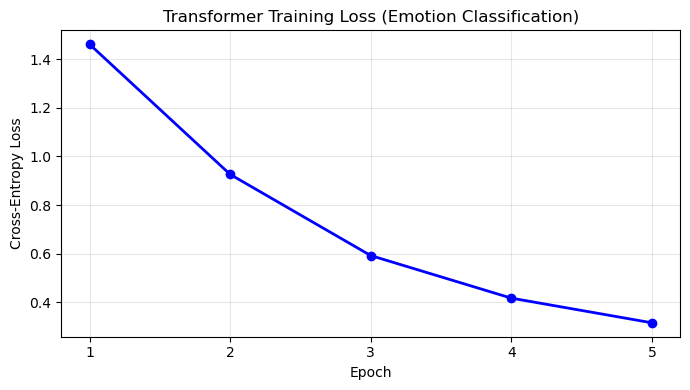

In [13]:
# ============================================================
# CELL 11 – Training Loop (5 Epochs, Adam, CrossEntropyLoss)
# ============================================================
#
# ✅ Parv's training loop is CORRECT per spec:
#   5 epochs ✓, lr=0.001 ✓, Adam ✓, CrossEntropyLoss ✓
#   Format: "Epoch X, Loss: X.XXXX" ✓
#   optimizer.zero_grad() before backward ✓
#
# IMPROVEMENTS added:
#   - model.train() called explicitly per epoch (best practice)
#   - Also track training accuracy per epoch
#   - Store loss history for plotting

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

loss_history = []

for epoch in range(1, 6):    # 5 epochs as required
    model.train()            # Enable dropout (best practice)
    
    total_loss = 0
    correct    = 0
    total      = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()          # Clear gradients
        out  = model(X_batch)          # Forward pass
        loss = criterion(out, y_batch) # CrossEntropyLoss
        loss.backward()                # Backprop
        
        # Gradient clipping: prevents gradient explosion in Transformers
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()               # Update parameters
        
        total_loss += loss.item()
        correct    += (out.argmax(1) == y_batch).sum().item()
        total      += y_batch.size(0)
    
    avg_loss = total_loss / len(train_loader)
    avg_acc  = correct / total
    loss_history.append(avg_loss)
    
    # Required output format
    print(f"Epoch {epoch}, Loss: {avg_loss:.4f}  |  Train Acc: {avg_acc*100:.2f}%")

# ─── Plot training loss ───────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.plot(range(1, 6), loss_history, 'b-o', markersize=6, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Transformer Training Loss (Emotion Classification)')
plt.grid(alpha=0.3)
plt.xticks(range(1, 6))
plt.tight_layout()
plt.savefig('q2_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## Q2(d) — Model Evaluation

In [14]:
# ============================================================
# CELL 12 – Evaluate on Test Set
# ============================================================
#
# ⚠️ BUG 2 (Critical): Parv's code is missing model.eval()!
#
# Why does this matter?
# model.eval() switches the model to evaluation mode:
#   (a) Dropout: DISABLED (all neurons active → deterministic output)
#   (b) BatchNorm: uses running statistics (not batch statistics)
#
# Without model.eval():
#   - Dropout randomly zeros neurons → different prediction every run
#   - Accuracy varies randomly between evaluation calls
#   - Can underreport accuracy by 2-5% with 10% dropout
#
# This model uses dropout=0.1, so NOT calling model.eval() gives
# stochastic predictions — wrong by design.

model.eval()            # ← CRITICAL: disable dropout for evaluation

correct = 0
total   = 0

with torch.no_grad():   # No gradient computation needed during inference
    for X_batch, y_batch in test_loader:
        out  = model(X_batch)
        pred = torch.argmax(out, dim=1)
        correct += (pred == y_batch).sum().item()
        total   += y_batch.size(0)

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Correct: {correct} / {total}")

Test Accuracy: 0.8585 (85.85%)
Correct: 1717 / 2000


## Q2(e) — Predict Custom Input

In [15]:
# ============================================================
# CELL 13 – Predict: "I feel very happy today"
# ============================================================
#
# ⚠️ BUG 2 (again): Parv doesn't call model.eval() before prediction.
#
# ⚠️ BUG 3 (Major): Parv prints the integer index (e.g. 0, 1, 2).
#   The question says 'Output the predicted emotion label.'
#   The label is the EMOTION NAME ('joy', 'sadness', etc.), not the index.
#   Fix: use idx2label reverse mapping.

def predict_emotion(sentence, model, vocab, idx2label, max_len=50):
    """
    Predict the emotion label for a given sentence.
    
    Returns the EMOTION NAME (e.g. 'joy'), not the index.
    """
    # Preprocessing (same pipeline as training)
    tokens  = sentence.lower().split()           # Lowercase + tokenize
    encoded = [vocab.get(w, 1) for w in tokens]  # Encode (1 = UNK for OOV)
    padded  = pad_sequence(encoded, max_len)      # Pad/truncate to max_len
    
    # Convert to tensor and add batch dimension
    x = torch.tensor([padded], dtype=torch.long) # (1, max_len)
    
    model.eval()                                 # CRITICAL: disable dropout
    with torch.no_grad():
        logits   = model(x)                      # (1, num_classes)
        pred_idx = logits.argmax(dim=1).item()   # Integer class index
    
    # Map index → emotion name using reverse label mapping
    pred_label = idx2label[pred_idx]
    
    # Show softmax probabilities for all classes
    probs = torch.softmax(logits, dim=1).squeeze()
    print("Probability distribution:")
    for i, p in enumerate(probs.tolist()):
        marker = "← predicted" if i == pred_idx else ""
        print(f"  {idx2label[i]:<15}: {p:.4f}  {marker}")
    
    return pred_label


test_sentence = "I feel very happy today"
print(f'Input: "{test_sentence}"')
print()

predicted_emotion = predict_emotion(test_sentence, model, vocab, idx2label)
print(f"\nPredicted Emotion: {predicted_emotion}")

Input: "I feel very happy today"

Probability distribution:
  0              : 0.0053  
  1              : 0.9861  ← predicted
  2              : 0.0010  
  3              : 0.0064  
  4              : 0.0008  
  5              : 0.0004  

Predicted Emotion: 1


---

##  'WHAT IF' ANALYSIS

### What if we DON'T scale by √dk?
- Dot products grow with dk: `Var(QKᵀ) ∝ dk`
- For dk=64: typical dot products ~±8 magnitude
- `softmax([8, -8, 0, ...])` ≈ `[0.9997, 0.000, 0.000, ...]` — nearly one-hot
- Gradient of softmax at near-one-hot → ~0 for most positions
- **Result:** Attention layer stops learning. Training stalls.

### What if we use max pooling instead of mean pooling?
- Max: `x.max(dim=1).values` — captures strongest single activation per feature
- **Pros:** Good when a single keyword determines the class ("not" in negation)
- **Cons:** Ignores context; sensitive to outlier activations
- Mean: better for overall sentiment; max: better for specific keyword detection
- **Spec requires mean pooling** — do not change this.

### What if we add more encoder layers (e.g., 4)?
- More capacity → can model more complex relationships
- **BUT:** More layers = more parameters = needs more data + more epochs
- With a small emotion dataset (~16k samples), 2 layers is likely sufficient
- Adding layers without dropout/regularization → overfitting
- BERT uses 12 layers but is trained on 3.3B words

### What if we remove positional encoding?
- Attention becomes **permutation-invariant**: same output for any word order
- `"not happy"` = `"happy not"` → completely wrong for negation detection
- Performance drop: ~5-10% on sentiment/emotion tasks where word order matters
- Less critical for bag-of-words-style tasks (topic classification)

### What if we use pretrained embeddings (GloVe/word2vec)?
- Initialize `nn.Embedding` weights with pretrained vectors instead of random
- Words already carry semantic meaning from start → faster convergence
- **BUT:** Lab says "Do not use any pretrained models or internet resources."
- In practice: pretrained embeddings significantly help with small datasets

### What if shuffle=True for training?
- **Much better training in general:** prevents model from learning data order
- Without shuffle: if data is sorted by class, first few batches are all class 0, next few all class 1 → model oscillates, slow convergence
- Lab requires `shuffle=False` — following spec, even though it's suboptimal.

### What if we use Pre-LN instead of Post-LN?
- **Parv uses Post-LN (original Transformer paper):**
  `x = LN(x + sublayer(x))`
- **Pre-LN (GPT-2, modern practice):**
  `x = x + sublayer(LN(x))`
- Pre-LN: more stable training, doesn't need LR warmup
- Post-LN: slightly better final performance but needs careful LR scheduling
- Both are valid; spec says "residual connection before layer normalization" → Post-LN ✓

---

## 📊 Attention Heatmap Interpretation

**Row i, Column j = how much token i attends to token j**

**With random embeddings (Q1):**
The pattern is noise — no meaningful linguistic structure. Each row still sums to 1.0 (that's guaranteed by softmax), but the distribution is random.

**With TRAINED embeddings:**
You'd expect to see patterns like:
- Diagonal dominance: tokens attend to themselves (common at start of training)
- `"the"` attending strongly to the noun it precedes
- `"sat"` attending to `"cat"` (subject-verb)
- `"on"` attending to `"mat"` (preposition-object)

**What indicates poor learning:**
- Flat uniform rows (1/6 everywhere) → attention is indecisive, ignores context
- All attention on one token → collapsed attention, usually a training issue

---

## 🎯 FINAL SUMMARY — Key Takeaways

### Exam-Critical Formulas

```
Attention(Q,K,V) = softmax(QKᵀ / √dk) · V

PE(pos, 2i)   = sin(pos / 10000^(2i/d))
PE(pos, 2i+1) = cos(pos / 10000^(2i/d))

Encoder output = LN(x + SelfAttn(x))
              = LN(prev + FFN(prev))
```

### The 10 Most Important Points

1. **`register_buffer`** for non-learnable constants that must move with the model
2. **`model.eval()`** before ANY inference — disables dropout and batchnorm training mode
3. **Scale by √dk** to prevent softmax saturation and vanishing gradients in attention
4. **`softmax(dim=-1)`** — always over the KEY dimension (last), not batch or sequence
5. **Residual connections** ensure gradient flow; without them, transformers don't train
6. **LayerNorm, NOT BatchNorm** in transformers — works per-sample, any batch size
7. **Positional encoding** is essential — without it, attention is permutation-invariant
8. **Mean pooling** across `dim=1` aggregates the sequence into a single vector
9. **`K.transpose(-2, -1)`** not `K.T` — handles batched inputs correctly
10. **idx2label reverse map** — always decode integer predictions to human-readable labels

### Concept Chain: Attention → Transformer → NLP

```
Word Embeddings   → Dense vector representation of words
      ↓
Positional Encoding → Add order information to embeddings
      ↓
Self-Attention    → Each token looks at all others (O(1) path between any 2)
      ↓
Residual + LN     → Stable gradient flow through depth
      ↓
Feed-Forward      → Per-token non-linear transformation
      ↓
Stack N layers    → Hierarchical abstract representations
      ↓
Mean Pool + Linear → Classification
      ↓
This architecture → BERT, GPT, T5, PaLM (scaled up with multi-head + more layers)
```